In [1]:
import pandas as pd
df = pd.read_csv("titanic.csv")

In [2]:
df.info

<bound method DataFrame.info of      survived  pclass     sex   age  sibsp  parch     fare embarked deck
0           0       3    male  22.0      1      0   7.2500        S  NaN
1           1       1  female  38.0      1      0  71.2833        C    C
2           1       3  female  26.0      0      0   7.9250        S  NaN
3           1       1  female  35.0      1      0  53.1000        S    C
4           0       3    male  35.0      0      0   8.0500        S  NaN
..        ...     ...     ...   ...    ...    ...      ...      ...  ...
886         0       2    male  27.0      0      0  13.0000        S  NaN
887         1       1  female  19.0      0      0  30.0000        S    B
888         0       3  female   NaN      1      2  23.4500        S  NaN
889         1       1    male  26.0      0      0  30.0000        C    C
890         0       3    male  32.0      0      0   7.7500        Q  NaN

[891 rows x 9 columns]>

In [5]:
df.describe(include=str)

,sex,embarked,deck
count,891,889,203
unique,2,3,7
top,male,S,C
freq,577,644,59


In [6]:
#rename columns
df.rename(columns={"parch":"parents_and_children"}) # pass inplace to save as always 

,survived,pclass,sex,age,sibsp,parents_and_children,fare,embarked,deck
0,0,3,male,22.0,1,0,7.2500,S,NaN
1,1,1,female,38.0,1,0,71.2833,C,C
2,1,3,female,26.0,0,0,7.9250,S,NaN
3,1,1,female,35.0,1,0,53.1000,S,C
4,0,3,male,35.0,0,0,8.0500,S,NaN
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,NaN
887,1,1,female,19.0,0,0,30.0000,S,B
888,0,3,female,NaN,1,2,23.4500,S,NaN
889,1,1,male,26.0,0,0,30.0000,C,C


In [ ]:
df.sort_values(by=["fare","pclass"],ascending=True) # or simply use one argument


,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
263,0,1,male,40.0,0,0,0.0000,S,B
633,0,1,male,NaN,0,0,0.0000,S,NaN
806,0,1,male,39.0,0,0,0.0000,S,A
815,0,1,male,NaN,0,0,0.0000,S,B
822,0,1,male,38.0,0,0,0.0000,S,NaN
...,...,...,...,...,...,...,...,...,...
341,1,1,female,24.0,3,2,263.0000,S,C
438,0,1,male,64.0,1,4,263.0000,S,C
258,1,1,female,35.0,0,0,512.3292,C,NaN
679,1,1,male,36.0,0,1,512.3292,C,B


In [8]:
df["pclass"].value_counts()
df[["pclass","survived"]].groupby("pclass").count()

,survived
pclass,
1,216
2,184
3,491


In [10]:
df["age"].value_counts(normalize=True,dropna=False)

age
NaN      0.198653
24.00    0.033670
22.00    0.030303
18.00    0.029181
28.00    0.028058
           ...   
24.50    0.001122
0.67     0.001122
0.42     0.001122
34.50    0.001122
74.00    0.001122
Name: proportion, Length: 89, dtype: float64

In [ ]:
#unique and nunique is super nice for exploring data and see values we want to use later

In [ ]:
df["deck"].unique() # uique values

<StringArray>
[nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Length: 8, dtype: str

In [ ]:
df["deck"].nunique() #nr of unique


7

In [15]:
# df.unique() this does not work for it we do
for col in df.columns:
    print(col, "\n", df[col].unique(), "\n") 

survived 
 [0 1] 

pclass 
 [3 1 2] 

sex 
 <StringArray>
['male', 'female']
Length: 2, dtype: str 

age 
 [22.   38.   26.   35.     nan 54.    2.   27.   14.    4.   58.   20.
 39.   55.   31.   34.   15.   28.    8.   19.   40.   66.   42.   21.
 18.    3.    7.   49.   29.   65.   28.5   5.   11.   45.   17.   32.
 16.   25.    0.83 30.   33.   23.   24.   46.   59.   71.   37.   47.
 14.5  70.5  32.5  12.    9.   36.5  51.   55.5  40.5  44.    1.   61.
 56.   50.   36.   45.5  20.5  62.   41.   52.   63.   23.5   0.92 43.
 60.   10.   64.   13.   48.    0.75 53.   57.   80.   70.   24.5   6.
  0.67 30.5   0.42 34.5  74.  ] 

sibsp 
 [1 0 3 4 2 5 8] 

parch 
 [0 1 2 5 3 4 6] 

fare 
 [  7.25    71.2833   7.925   53.1      8.05     8.4583  51.8625  21.075
  11.1333  30.0708  16.7     26.55    31.275    7.8542  16.      29.125
  13.      18.       7.225   26.       8.0292  35.5     31.3875 263.
   7.8792   7.8958  27.7208 146.5208   7.75    10.5     82.1708  52.
   7.2292  11.2417   

In [ ]:
df["age"].nlargest() # 10 by default can be change to "X" ammount with (...).nlargest(X) 

630    80.0
851    74.0
96     71.0
493    71.0
116    70.5
Name: age, dtype: float64

In [17]:
df["age"].mean()
df.mean(numeric_only=True)

survived     0.383838
pclass       2.308642
age         29.699118
sibsp        0.523008
parch        0.381594
fare        32.204208
dtype: float64

In [21]:
df.agg("mean",numeric_only=True)

survived     0.383838
pclass       2.308642
age         29.699118
sibsp        0.523008
parch        0.381594
fare        32.204208
dtype: float64

In [20]:
df.agg("mean", numeric_only=True)

survived     0.383838
pclass       2.308642
age         29.699118
sibsp        0.523008
parch        0.381594
fare        32.204208
dtype: float64

TypeError: Cannot perform reduction 'mean' with string dtype

In [26]:
df.select_dtypes(include="number").agg(["mean", "median"])

,survived,pclass,age,sibsp,parch,fare
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
median,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200


In [28]:
corr = df.select_dtypes(include="number").corr()

<Axes: >

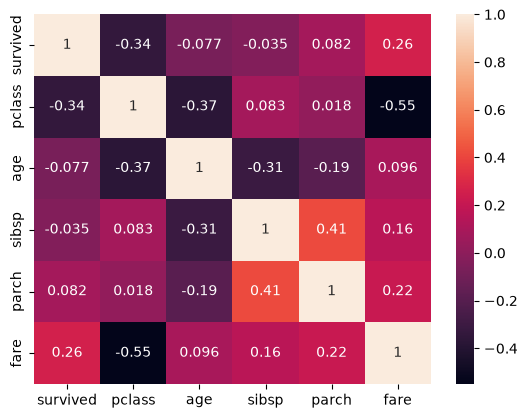

In [30]:
import seaborn as sns
sns.heatmap(corr,annot=True)

In [ ]:
df["age"].apply(lambda x: "child" if x > 15 else "adult") #obv u can def your own func and parse it inside

0      child
1      child
2      child
3      child
4      child
       ...  
886    child
887    child
888    adult
889    child
890    child
Name: age, Length: 891, dtype: str

In [ ]:
def adult_or_child(x):
    if x > 15:
        return "child" 
    else:
        return "adult"
df["adult_or_child"] = df.age.apply(adult_or_child)

In [32]:
#map 
classes = {1: "1st Classs", 2: "2nd Class", 3: "3rd Class"}
df["pclass"].map(classes)

0       3rd Class
1      1st Classs
2       3rd Class
3      1st Classs
4       3rd Class
          ...    
886     2nd Class
887    1st Classs
888     3rd Class
889    1st Classs
890     3rd Class
Name: pclass, Length: 891, dtype: str

In [ ]:
#pd.cut and pd.qcut

#cut bins fixed values ranges

pd.cut(df["age"], bins=[0,25,50,100]) 

0       (0.0, 25.0]
1      (25.0, 50.0]
2      (25.0, 50.0]
3      (25.0, 50.0]
4      (25.0, 50.0]
           ...     
886    (25.0, 50.0]
887     (0.0, 25.0]
888             NaN
889    (25.0, 50.0]
890    (25.0, 50.0]
Name: age, Length: 891, dtype: category
Categories (3, interval[int64, right]): [(0, 25] < (25, 50] < (50, 100]]

In [34]:
pd.cut(df["age"], bins=[0,25,50,100]).value_counts()

age
(25, 50]     349
(0, 25]      301
(50, 100]     64
Name: count, dtype: int64

In [36]:
pd.cut(df["age"], bins=[0,25,50,100], labels=["youngsters","middle age","oldies"]).value_counts()

age
middle age    349
youngsters    301
oldies         64
Name: count, dtype: int64

In [37]:
pd.qcut(df["fare"],q=4,labels=["cheap","low price","med price","high price"])

0           cheap
1      high price
2       low price
3      high price
4       low price
          ...    
886     low price
887     med price
888     med price
889     med price
890         cheap
Name: fare, Length: 891, dtype: category
Categories (4, str): ['cheap' < 'low price' < 'med price' < 'high price']

In [38]:
pd.qcut(df["fare"],q=4,labels=["cheap","low price","med price","high price"]).value_counts()


fare
low price     224
cheap         223
med price     222
high price    222
Name: count, dtype: int64

<Axes: xlabel='age', ylabel='fare'>

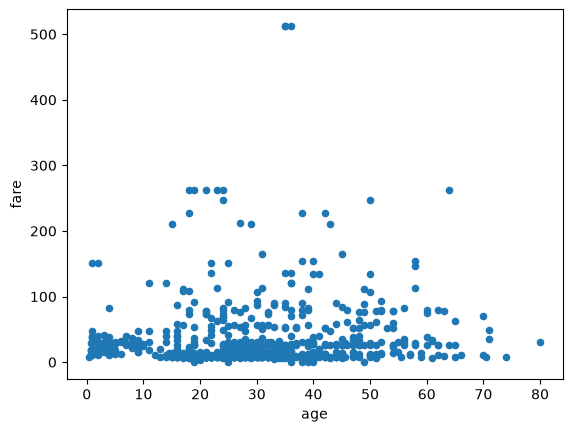

In [39]:
df.plot(kind="scatter", x="age", y="fare")